In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\Projects\complete_ab_test\ab_test_dataset.csv")

In [3]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [4]:
df['Group'].unique()

array(['B', 'A'], dtype=object)

In [5]:
df['Group'].value_counts()

Group
A    2519
B    2481
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [24]:
df.describe()

,User ID,Page Views,Time Spent
count,5000.000000,5000.000000,5000.000000
mean,14925.159000,7.537600,242.512600
std,2869.153773,4.022465,118.254153
min,10001.000000,1.000000,40.000000
25%,12456.250000,4.000000,137.000000
50%,14858.500000,8.000000,243.000000
75%,17379.750000,11.000000,346.000000
max,19995.000000,14.000000,449.000000


In [7]:
from scipy.stats import chisquare

observed = [2519, 2481]
expected = [2500, 2500]

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print(chi2)
print(p_value)

0.2888
0.5909905465803058


In [8]:
df.groupby('Group')['Conversion'].value_counts()

Group  Conversion
A      No            2383
       Yes            136
B      No            2132
       Yes            349
Name: count, dtype: int64

# Does the new background color change the conversion rate?

# Conversion Rate

In [34]:
control_cr= 136/2519
treatment_cr=349/2481

print(f'control_cr: {control_cr:.2f}')
print(f'treatment_cr: {treatment_cr:.2f}')
print(f'absolute_lift : {treatment_cr-control_cr}')
print(f'relative_lift : {100*(treatment_cr-control_cr)/control_cr}')

control_cr: 0.05
treatment_cr: 0.14
absolute_lift : 0.08667940660252538
relative_lift : 160.54810678805987


# Conclusion:
The treatment group achieved a higher conversion rate than the control group. While this suggests a potential improvement, statistical testing is required to determine whether the observed difference is statistically significant or simply due to random variation.

# Two Proportions Z-test

**Null Hypothesis : Control and treatment group have equal Conversion rate.      
Alternative Hypothesis : Conversion rate is different for control and treatment group**

In [40]:
from statsmodels.stats.proportion import proportions_ztest

success=[349,136]
visitors=[2481,2519]

z_stat,p_value= proportions_ztest(success,visitors,alternative='two-sided')

print(f'z_stat: {z_stat:.2f}')
print(f'p_value: {p_value}')

if p_value<0.05:
    print('Reject Null Hypothesis')
else:
    print('Fail to Reject Null Hypothesis')

z_stat: 10.35
p_value: 3.9931511894201938e-25
Reject Null Hypothesis


# Conclusion:
The Two-Proportion Z-Test produced an extremely small p-value (p < 0.001), indicating strong statistical evidence against the null hypothesis. Therefore, the increase in conversion rate observed in the treatment group is statistically significant and is unlikely to have occurred by chance.

# Confidence Interval

In [28]:
from statsmodels.stats.proportion import confint_proportions_2indep

low,high= confint_proportions_2indep(349,2481,136,2519,method='wald')

print(f'low: {low:.2f}')
print(f'high: {high:.2f}')

low: 0.07
high: 0.10


# Conclusion:
The 95% confidence interval for the difference in conversion rates does not include zero, indicating that the improvement is statistically significant. The interval suggests that the treatment consistently outperformed the control, providing additional confidence in the observed lift.

In [12]:
import statsmodels

print(statsmodels.__version__)

0.14.5


In [13]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [14]:
df.groupby('Group')['Time Spent'].mean()

Group
A    241.733227
B    243.303910
Name: Time Spent, dtype: float64

# Does the new background color change the average time users spend on the website?

# T-test for Time Spent

In [35]:
from scipy.stats import ttest_ind

control_A = df[df['Group']=='A']['Time Spent']
treatment_B = df[df['Group']=='B']['Time Spent']

t_stat,p_value = ttest_ind(treatment_B,control_A,equal_var=False)

print(f't_stat : {t_stat}')
print(f'p_value : {p_value}')

t_stat : 0.4694926489675219
p_value : 0.6387380383087231


# Conclusion:
The Welch's t-test showed no statistically significant difference in the average time spent between the control and treatment groups (p > 0.05). This suggests that the new background color did not meaningfully affect how long users remained on the website.

# Does the new background color affect the average number of page views?

# T-test for Pages Viewed

In [36]:
control_v_A = df[df['Group']=='A']['Page Views']
treatment_v_B = df[df['Group']=='B']['Page Views']

print(page_v_B)

0        3
3        4
5        2
7        9
8        8
        ..
4993     5
4994    10
4995    12
4996    10
4998    13
Name: Page Views, Length: 2481, dtype: int64


In [37]:
t_stat,p_value= ttest_ind(treatment_v_B,control_v_A,equal_var=False)

print(f't_stat : {t_stat}')
print(f'p_value : {p_value}')

t_stat : -0.779161052451573
p_value : 0.4359217464384032


# Conclusion:
No statistically significant difference was observed in the average number of page views between the two groups. The treatment did not appear to influence how many pages users visited during their session.

# Are device types distributed equally between the treatment and control groups?

# Chi-square test for Device

In [20]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df["Group"], df["Device"])

print(table)

Device  Desktop  Mobile
Group                  
A          1244    1275
B          1294    1187


In [31]:
# Run Chi-Square Test of Independence
chi2, p_value, dof, expected = chi2_contingency(table)
print('Device:')
print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Device:
Chi-Square Statistic: 3.731765848529103
P-value: 0.05338692515743378
Degrees of Freedom: 1
Expected Frequencies:
[[1278.6444 1240.3556]
 [1259.3556 1221.6444]]


# Conclusion:
The Chi-Square Test of Independence indicated no statistically significant difference in device distribution between the control and treatment groups. This suggests that the experiment was well randomized with respect to device type, reducing the likelihood of device-related bias.

# Are locations distributed equally between the treatment and control groups?

# Chi-square test for Location

In [22]:
location_table = pd.crosstab(df['Group'],df['Location'])

print(location_table)

Location  England  Northern Ireland  Scotland  Wales
Group                                               
A             606               614       670    629
B             640               628       611    602


In [32]:
chi2, p_value, dof, expected = chi2_contingency(location_table)
print('Location:')
print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)

Location:
Chi-Square Statistic: 4.10662577996627
P-value: 0.2501782724258139
Degrees of Freedom: 3
Expected Frequencies:
[[627.7348 625.7196 645.3678 620.1778]
 [618.2652 616.2804 635.6322 610.8222]]


# Conclusion:
The location distribution was found to be similar across both experimental groups. This provides additional evidence that the randomization process was successful and that location is unlikely to have influenced the observed treatment effect.

# Executive Summary / Key Findings
**1. The treatment group achieved a significantly higher conversion rate than the control group.       
2. No statistically significant differences were observed in time spent or page views.     
3. Device and location distributions were balanced across the two groups, indicating successful randomization.      
4. The experiment provides strong evidence that the treatment improved conversions.**    

# Business Recommendation

**Based on the statistical analysis, the treatment is recommended for deployment. The conversion rate increased significantly, while no adverse effects were observed on user engagement metrics such as page views and time spent. Additionally, the randomization checks confirmed that the control and treatment groups were well balanced, increasing confidence that the observed improvement was caused by the experimental change rather than external factors. It is recommended to continue monitoring conversion rate and guardrail metrics after deployment to ensure the improvement is sustained in a production environment.**

# Limitations

**1. This analysis was performed on a synthetic dataset.      
2. Only device type and location were available for randomization checks.      
3. Additional user characteristics could further validate the experiment.      
4. Post-launch monitoring is recommended to confirm that the observed improvement persists over time.**

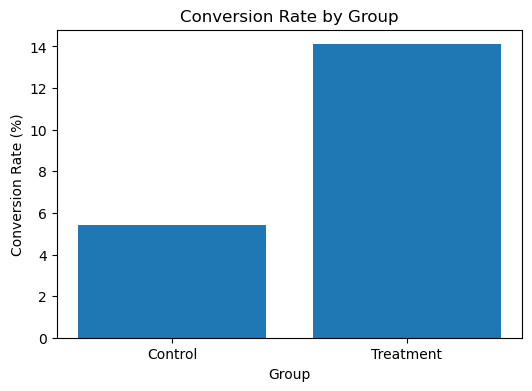

In [49]:
import matplotlib.pyplot as plt

groups = ["Control", "Treatment"]
conversion_rate = [5.4, 14.1]

plt.figure(figsize=(6,4))
plt.bar(groups, conversion_rate)
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")


plt.show()

In [42]:
avg_time = df.groupby("Group")["Time Spent"].mean()
print(avg_time)

Group
A    241.733227
B    243.303910
Name: Time Spent, dtype: float64


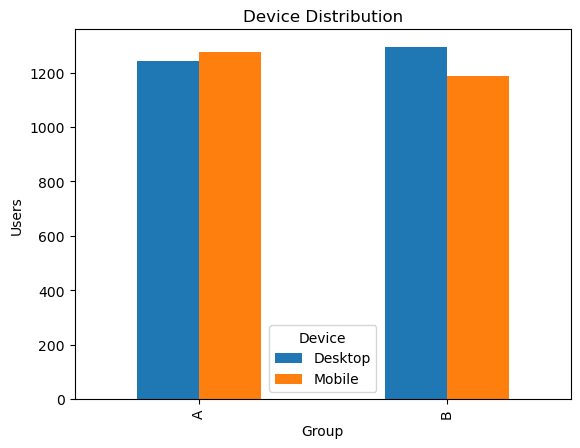

In [44]:
device = pd.crosstab(df["Group"], df["Device"])

device.plot(kind="bar")

plt.title("Device Distribution")
plt.xlabel("Group")
plt.ylabel("Users")

plt.show()

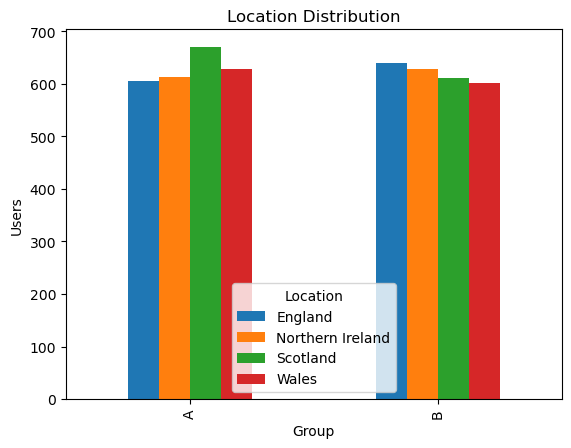

In [45]:
location = pd.crosstab(df["Group"], df["Location"])

location.plot(kind="bar")

plt.title("Location Distribution")
plt.xlabel("Group")
plt.ylabel("Users")

plt.show()

<Figure size 600x400 with 0 Axes>

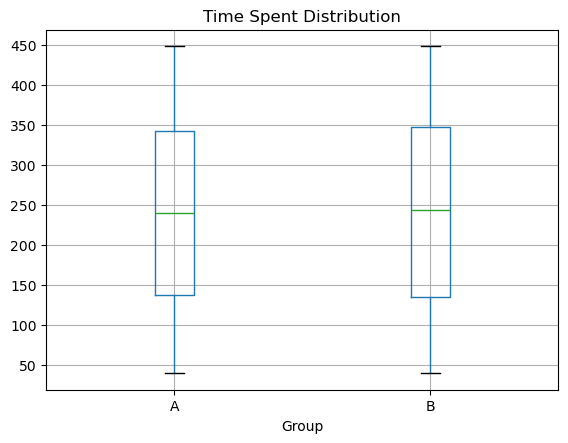

In [46]:
plt.figure(figsize=(6,4))

df.boxplot(column="Time Spent", by="Group")

plt.title("Time Spent Distribution")
plt.suptitle("")

plt.show()

<Figure size 600x400 with 0 Axes>

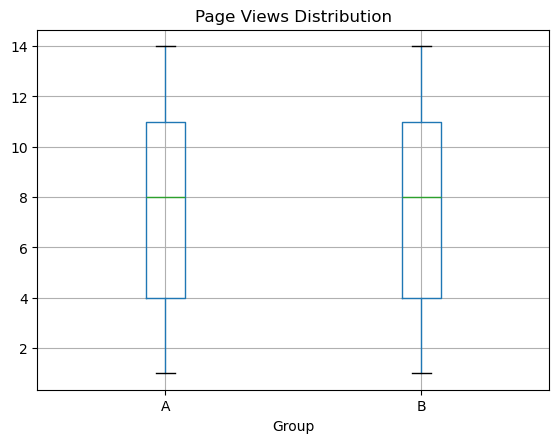

In [47]:
plt.figure(figsize=(6,4))

df.boxplot(column="Page Views", by="Group")

plt.title("Page Views Distribution")
plt.suptitle("")

plt.show()